# PartitionTree — Probabilistic Regression with skpro

This notebook demonstrates **probabilistic regression** using `PartitionTreeRegressorSkpro` from the `partition_tree` library. Unlike a point-estimate regressor, this model returns a full **probability distribution** (`IntervalDistribution`) for each prediction, enabling uncertainty quantification out of the box.

We use the **California Housing** dataset and show how to:
1. Fit the model and obtain distributional predictions.
2. Extract point estimates (mean, median) and prediction intervals.
3. Evaluate with proper scoring rules (CRPS) and compare against `PartitionForestRegressorSkpro`.
4. Visualise the predictive PDF for individual test samples.

## 1. Import Required Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

from partition_tree.skpro import PartitionTreeRegressor, PartitionForestRegressor

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

## 2. Load and Explore the Dataset

We use the **California Housing** dataset (20 640 samples, 8 features). The target is **median house value** in units of $100 000.

In [2]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame

print(f"Shape : {df.shape}")
print(f"Target: {housing.target_names}")
df.head()

Shape : (20640, 9)
Target: ['MedHouseVal']


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 3. Preprocess the Data

Split into train / test sets (80 / 20) and scale features with `StandardScaler`.  
The skpro estimators accept **pandas DataFrames**, so we keep the data in that format.

In [3]:
X = housing.data
y = housing.target.rename("MedHouseVal")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test), columns=X_test.columns, index=X_test.index
)

print(f"Training set : {X_train_scaled.shape}")
print(f"Test set     : {X_test_scaled.shape}")

Training set : (16512, 8)
Test set     : (4128, 8)


## 4. Fit `PartitionTreeRegressorSkpro`

`PartitionTreeRegressorSkpro` extends skpro's `BaseProbaRegressor`. Calling `predict_proba` returns an `IntervalDistribution` — a piecewise-constant PDF defined over disjoint intervals.

In [15]:
pt = PartitionTreeRegressor(
    max_leaves=200,
    max_depth=30,
    min_samples_split=1,
    min_samples_x=5,
    min_volume_fraction=.05,
)

pt.fit(X_train_scaled, y_train)
print("PartitionTreeRegressorSkpro fitted.")

PartitionTreeRegressorSkpro fitted.


<Axes: xlabel='x', ylabel='PDF'>

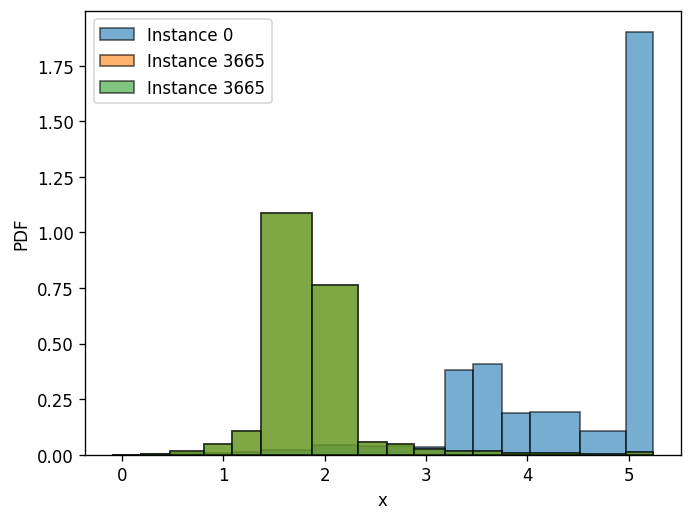

In [16]:
y_pred_proba = pt.predict_proba(X_test_scaled)
y_pred_proba.loc[[0,1,2]].plot()

## 5. Probabilistic Predictions

`predict_proba` returns an `IntervalDistribution`. From it we can extract:
- **`mean()`** — posterior mean (point estimate)
- **`ppf(q)`** — quantiles / prediction intervals (e.g. 10th–90th percentile)

In [17]:
# Distributional predictions
dist = pt.predict_proba(X_test_scaled)

# Point estimates from the distribution
y_pred_mean   = pt.predict(X_test_scaled)  # posterior mean
y_pred_median = dist.ppf(0.5)["MedHouseVal"]               # posterior median

# 80% prediction interval  [10th, 90th percentile]
lower_80 = dist.ppf(0.10)["MedHouseVal"]
upper_80 = dist.ppf(0.90)["MedHouseVal"]

summary = pd.DataFrame({
    "Actual"       : y_test.values[:10],
    "Mean pred"    : y_pred_mean.values[:10].round(3),
    "Median pred"  : y_pred_median.values[:10].round(3),
    "PI 10%"       : lower_80.values[:10].round(3),
    "PI 90%"       : upper_80.values[:10].round(3),
}, index=y_test.index[:10])
summary

,Actual,Mean pred,Median pred,PI 10%,PI 90%
20046,0.47700,0.908,0.690,0.507,1.728
3024,0.45800,1.042,0.719,0.523,2.377
15663,5.00001,3.047,2.701,1.921,5.018
20484,2.18600,2.818,2.751,2.013,3.768
9814,2.78000,2.591,2.514,1.749,3.591
13311,1.58700,2.137,2.088,1.379,3.015
7113,1.98200,2.392,2.238,1.634,3.553
7668,1.57500,1.843,1.769,1.435,2.270
18246,3.40000,2.787,2.717,1.360,4.276
5723,4.46600,4.370,4.979,3.255,5.190


## 6. Evaluate the Model

### 6.1 Point-estimate metrics (MAE, R²)

In [18]:
mae = mean_absolute_error(y_test, y_pred_mean)
r2  = r2_score(y_test, y_pred_mean)

print(f"MAE : {mae:.4f}  (×$100k)")
print(f"R²  : {r2:.4f}")

MAE : 0.4692  (×$100k)
R²  : 0.6737


### 6.2 Interval coverage

An 80% prediction interval should cover ~80% of the true values.

In [19]:
y_true_vals = y_test.values
covered_80 = ((y_true_vals >= lower_80.values) & (y_true_vals <= upper_80.values)).mean()

# Also compute 50% PI (25th–75th) coverage
lower_50 = dist.ppf(0.25)["MedHouseVal"]
upper_50 = dist.ppf(0.75)["MedHouseVal"]
covered_50 = ((y_true_vals >= lower_50.values) & (y_true_vals <= upper_50.values)).mean()

coverage_df = pd.DataFrame({
    "PI"            : ["50% PI (Q25–Q75)", "80% PI (Q10–Q90)"],
    "Expected cov." : [0.50, 0.80],
    "Actual cov."   : [round(covered_50, 4), round(covered_80, 4)],
})
coverage_df

,PI,Expected cov.,Actual cov.
0,50% PI (Q25–Q75),0.5,0.6226
1,80% PI (Q10–Q90),0.8,0.8665


### 6.3 Compare with `PartitionForestRegressorSkpro`

The forest variant averages distributions from multiple trees via `IntervalDistribution.from_mixture`, often yielding smoother and better-calibrated predictions.

In [26]:
pf = PartitionForestRegressor(
    n_estimators=50,
    max_leaves=200,
    max_depth=30,
    min_samples_split=1,
    min_samples_x=5,
    min_volume_fraction=.05,
    random_state=42,
    output_distribution="merged"
)
pf.fit(X_train_scaled, y_train)
print("PartitionForestRegressorSkpro fitted.")

dist_forest = pf.predict_proba(X_test_scaled)
y_pred_forest = pf.predict(X_test_scaled)

lower_80_f = dist_forest.ppf(0.10)["MedHouseVal"]
upper_80_f = dist_forest.ppf(0.90)["MedHouseVal"]
covered_80_f = ((y_true_vals >= lower_80_f.values) & (y_true_vals <= upper_80_f.values)).mean()

compare_df = pd.DataFrame({
    "Model"        : ["PartitionTreeRegressorSkpro", "PartitionForestRegressorSkpro"],
    "MAE"          : [
        round(mean_absolute_error(y_test, y_pred_mean), 4),
        round(mean_absolute_error(y_test, y_pred_forest), 4),
    ],
    "R²"           : [
        round(r2_score(y_test, y_pred_mean), 4),
        round(r2_score(y_test, y_pred_forest), 4),
    ],
    "80% coverage" : [round(covered_80, 4), round(covered_80_f, 4)],
}).set_index("Model")
compare_df

PartitionForestRegressorSkpro fitted.


,MAE,R²,80% coverage
Model,,,
PartitionTreeRegressorSkpro,0.4692,0.6737,0.8665
PartitionForestRegressorSkpro,0.4506,0.7005,0.9026


In [27]:
from skpro.metrics import LogLoss


logloss = LogLoss()

logloss_score_pt = logloss(y_test, dist)
logloss_score_pf = logloss(y_test, dist_forest)
logloss_df = pd.DataFrame({
    "Model"    : ["PartitionTreeRegressorSkpro", "PartitionForestRegressorSkpro"],
    "LogLoss"  : [round(logloss_score_pt, 4), round(logloss_score_pf, 4)],
}).set_index("Model")
logloss_df

,LogLoss
Model,
PartitionTreeRegressorSkpro,0.7379
PartitionForestRegressorSkpro,0.6141


In [28]:
proba_per_tree = pf.predict_proba_per_tree(X_test_scaled)


<Axes: xlabel='x', ylabel='PDF'>

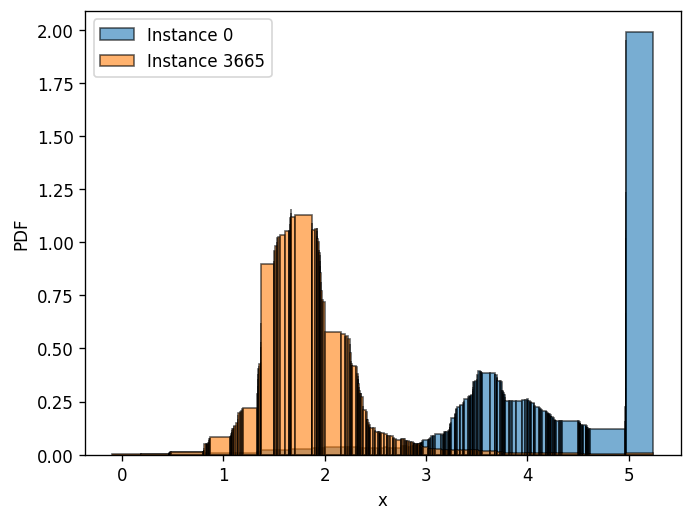

In [29]:
dist_forest.loc[[0,1]].plot()

## 7. Visualise the Results

### 7.1 Predicted mean vs Actual with 80% prediction intervals

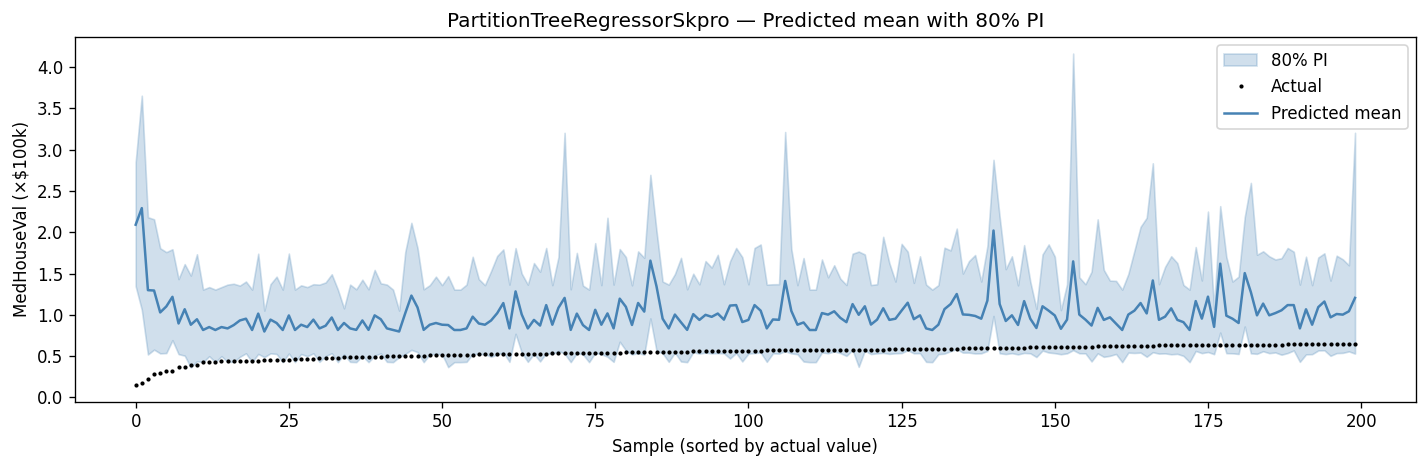

In [13]:
# Sort by actual value for a cleaner ribbon plot
n_show = 200
sort_idx = np.argsort(y_test.values)[:n_show]

actual_sorted = y_test.values[sort_idx]
mean_sorted   = y_pred_mean.values[sort_idx]
lo_sorted     = lower_80.values[sort_idx]
hi_sorted     = upper_80.values[sort_idx]

fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(range(n_show), lo_sorted, hi_sorted,
                alpha=0.25, color="steelblue", label="80% PI")
ax.plot(range(n_show), actual_sorted, "k.", ms=3, label="Actual")
ax.plot(range(n_show), mean_sorted, color="steelblue", lw=1.5, label="Predicted mean")
ax.set_xlabel("Sample (sorted by actual value)")
ax.set_ylabel("MedHouseVal (×$100k)")
ax.set_title("PartitionTreeRegressorSkpro — Predicted mean with 80% PI")
ax.legend()
plt.tight_layout()
plt.show()

### 7.3 Prediction interval width distribution

Wider intervals indicate higher uncertainty. This plot shows how interval widths are distributed across the test set.

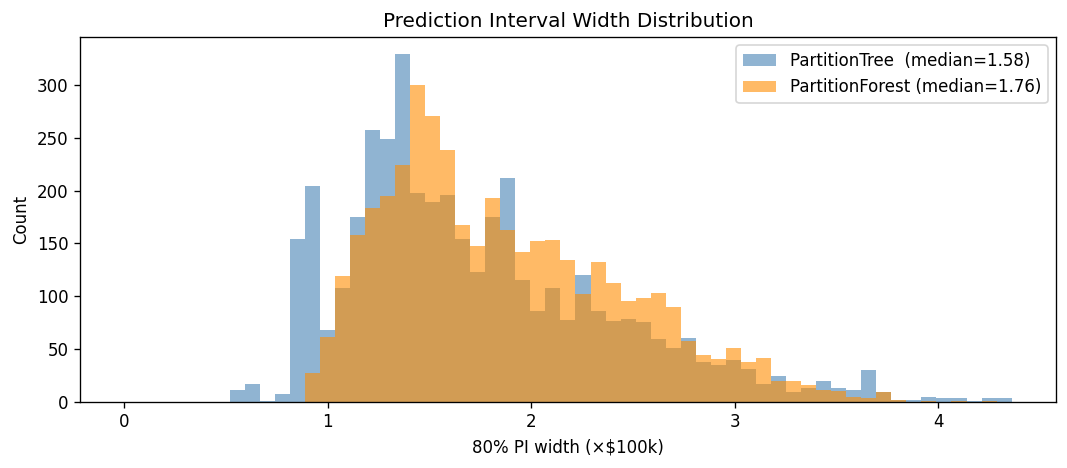

In [14]:
widths_pt = (upper_80.values - lower_80.values)
widths_pf = (upper_80_f.values - lower_80_f.values)

fig, ax = plt.subplots(figsize=(9, 4))
bins = np.linspace(0, max(widths_pt.max(), widths_pf.max()), 60)
ax.hist(widths_pt, bins=bins, alpha=0.6, color="steelblue",
        label=f"PartitionTree  (median={np.median(widths_pt):.2f})")
ax.hist(widths_pf, bins=bins, alpha=0.6, color="darkorange",
        label=f"PartitionForest (median={np.median(widths_pf):.2f})")
ax.set_xlabel("80% PI width (×$100k)")
ax.set_ylabel("Count")
ax.set_title("Prediction Interval Width Distribution")
ax.legend()
plt.tight_layout()
plt.show()